# ==========================================
# Load Data
# ==========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os


print("Loading raw training and testing data...")
X_train = pd.read_csv('../data/X_train_clean_raw.csv')
X_test = pd.read_csv('../data/X_test_clean_raw.csv')
y_train = pd.read_csv('../data/y_train_clean.csv').values.ravel()
y_test = pd.read_csv('../data/y_test_clean.csv').values.ravel()

feature_names = X_train.columns.tolist()

# Helper function for Permutation Importance Plots
def plot_permutation_importance(model, X_val, y_val, title, color):
    print(f"Calculating Permutation Importance for {title}... (this takes a few seconds)")
    result = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
    
    # Sort features by importance
    sorted_idx = result.importances_mean.argsort()
    
    plt.figure(figsize=(8, 4))
    plt.barh(range(X_val.shape[1]), result.importances_mean[sorted_idx], color=color)
    plt.yticks(range(X_val.shape[1]), np.array(feature_names)[sorted_idx])
    plt.title(title, fontweight='bold')
    plt.xlabel('Mean Decrease in Accuracy')
    plt.tight_layout()
    plt.show()

Loading raw training and testing data...


# ==========================================
# STAGE 1: General (0) vs. Specialized (1 & 2)
# ==========================================


 STAGE 1: General Blood Draw vs. Specialized Ward (HistBoost)

Stage 1 Accuracy: 81.67%

Classification Report (Stage 1):
              precision    recall  f1-score   support

     General       0.74      0.69      0.71      1567
 Specialized       0.85      0.88      0.87      3135

    accuracy                           0.82      4702
   macro avg       0.80      0.78      0.79      4702
weighted avg       0.81      0.82      0.81      4702



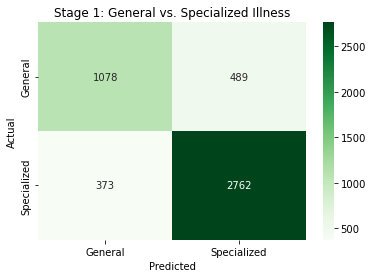

Calculating Permutation Importance for Stage 1: Top Features (Finding Sickness)... (this takes a few seconds)


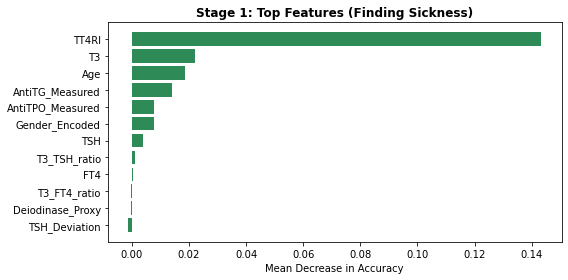

In [2]:
print("\n" + "="*50)
print(" STAGE 1: General Blood Draw vs. Specialized Ward (HistBoost)")
print("="*50)

y_train_s1 = np.where(y_train == 0, 0, 1) 
y_test_s1 = np.where(y_test == 0, 0, 1)

hb_model_s1 = HistGradientBoostingClassifier(max_iter=300, max_depth=5, learning_rate=0.05, random_state=42)
hb_model_s1.fit(X_train, y_train_s1)

pred_s1 = hb_model_s1.predict(X_test)
print(f"\nStage 1 Accuracy: {accuracy_score(y_test_s1, pred_s1):.2%}")
print("\nClassification Report (Stage 1):")
print(classification_report(y_test_s1, pred_s1, target_names=['General', 'Specialized']))

# --- Stage 1 Confusion Matrix ---
cm1 = confusion_matrix(y_test_s1, pred_s1)
cm1_percent = cm1.astype('float') / cm1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['General', 'Specialized'], yticklabels=['General', 'Specialized'])
plt.title('Stage 1: General vs. Specialized Illness')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- Stage 1 Permutation Importance ---
plot_permutation_importance(hb_model_s1, X_test, y_test_s1, 'Stage 1: Top Features (Finding Sickness)', 'seagreen')

# ==========================================
# STAGE 2: Kardiologiki (1) vs. Nefrologiki (2)
# ==========================================


 STAGE 2: Cardiology vs. Nephrology (HistBoost with Threshold Tuning)

Stage 2 Accuracy (Threshold = 0.58): 74.23%

Classification Report (Stage 2):
              precision    recall  f1-score   support

Kardiologiki       0.74      0.75      0.74      1567
 Nefrologiki       0.74      0.74      0.74      1568

    accuracy                           0.74      3135
   macro avg       0.74      0.74      0.74      3135
weighted avg       0.74      0.74      0.74      3135



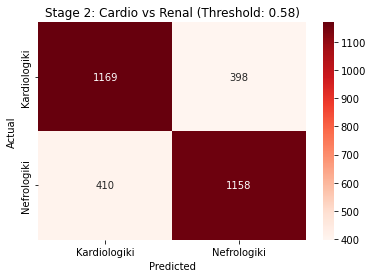

Calculating Permutation Importance for Stage 2: Top Features (Finding Organ Failure)... (this takes a few seconds)


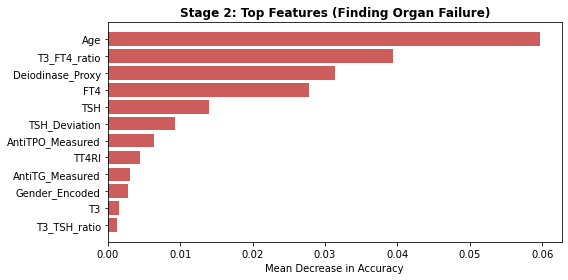

In [3]:
print("\n" + "="*50)
print(" STAGE 2: Cardiology vs. Nephrology (HistBoost with Threshold Tuning)")
print("="*50)

train_mask = (y_train != 0)
test_mask = (y_test != 0)

X_train_s2 = X_train[train_mask]
y_train_s2 = y_train[train_mask] - 1 
X_test_s2 = X_test[test_mask]
y_test_s2 = y_test[test_mask] - 1

hb_model_s2 = HistGradientBoostingClassifier(max_iter=300, max_depth=5, learning_rate=0.05, random_state=42)
hb_model_s2.fit(X_train_s2, y_train_s2)

# --- THRESHOLD TUNING ---
probs_s2 = hb_model_s2.predict_proba(X_test_s2)[:, 1]
custom_threshold = 0.58  
pred_s2_custom = (probs_s2 >= custom_threshold).astype(int)

print(f"\nStage 2 Accuracy (Threshold = {custom_threshold}): {accuracy_score(y_test_s2, pred_s2_custom):.2%}")
print("\nClassification Report (Stage 2):")
print(classification_report(y_test_s2, pred_s2_custom, target_names=['Kardiologiki', 'Nefrologiki']))

# --- Stage 2 Confusion Matrix ---
cm2 = confusion_matrix(y_test_s2, pred_s2_custom)

plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Kardiologiki', 'Nefrologiki'], yticklabels=['Kardiologiki', 'Nefrologiki'])
plt.title(f'Stage 2: Cardio vs Renal (Threshold: {custom_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- Stage 2 Permutation Importance ---
plot_permutation_importance(hb_model_s2, X_test_s2, y_test_s2, 'Stage 2: Top Features (Finding Organ Failure)', 'indianred')

# ==========================================
# Save Models
# ==========================================

In [4]:
os.makedirs('models', exist_ok=True)
joblib.dump(hb_model_s1, 'models/hierarchical_stage1_hist.pkl')
joblib.dump(hb_model_s2, 'models/hierarchical_stage2_hist.pkl')
print("\n Both HistBoost Stages successfully trained and saved!")


 Both HistBoost Stages successfully trained and saved!
